In [1]:
from ipywidgets import FileUpload
import io
import numpy as np
from matplotlib import pyplot as plt

upload = FileUpload(accept='image/*', multiple=False)
display(upload)


FileUpload(value=(), accept='image/*', description='Upload')

In [2]:
def read_image(upload_widget):
    if len(upload_widget.value) == 0:
        print("Silakan upload gambar terlebih dahulu.")
        return None

    # Ambil file pertama dari tuple
    file_info = upload_widget.value[0]

    image_data = plt.imread(io.BytesIO(file_info['content']))
    if image_data.dtype == np.float32 or image_data.dtype == np.float64:
        image_data = (image_data * 255).astype(np.uint8)
    return image_data

img = read_image(upload)



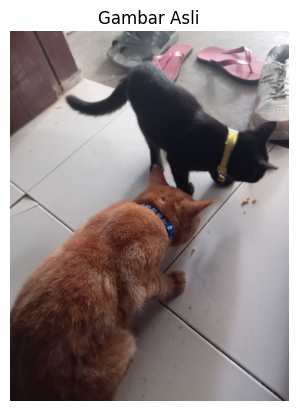

In [3]:
# Cell 2: Membaca gambar yang diupload dan menampilkannya
if len(upload.value) > 0:  # Mengecek apakah ada file yang diupload
    image_data = read_image(upload)  # Panggil fungsi untuk membaca gambar
    
    if image_data is not None:
        plt.imshow(image_data)
        plt.axis('off')  # Menghilangkan axis
        plt.title("Gambar Asli")
        plt.show()  # Menampilkan gambar yang diupload
    else:
        print("Gagal memuat gambar.")
else:
    print("Silakan upload gambar terlebih dahulu.")


In [6]:
def to_indexed(img):
    palette = [
    [0, 0, 0],         # Hitam
    [127, 127, 127],   # Abu-abu
    [255, 255, 255]    # Putih
]
    height = len(img)
    width = len(img[0])
    indexed_img = []

    for i in range(height):
        row = []
        for j in range(width):
            pixel = img[i][j][:3]
            min_dist = float('inf')
            nearest = [0, 0, 0]

            for color in palette:
                dist = 0
                for k in range(3):
                    dist += (int(pixel[k]) - color[k]) ** 2
                if dist < min_dist:
                    min_dist = dist
                    nearest = color
            row.append(nearest)
        indexed_img.append(row)

    return indexed_img


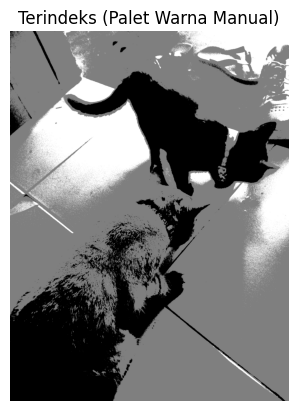

In [7]:
import numpy as np

indexed = to_indexed(img)
indexed_array = np.array(indexed, dtype=np.uint8)

plt.imshow(indexed_array)
plt.title("Terindeks (Palet Warna Manual)")
plt.axis('off')
plt.show()
